## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

C:\Users\darya.LAPTOP-E5VAOAQ9\anconda\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 2. Generate Synthetic House Dataset

We simulate a realistic housing dataset with features like area, bedrooms, bathrooms, location score, age, and garage.

In [3]:
np.random.seed(42)
n = 500

# Features
area          = np.random.randint(500, 5000, n)          # sq ft
bedrooms      = np.random.randint(1, 6, n)
bathrooms     = np.random.randint(1, 4, n)
age           = np.random.randint(0, 50, n)              # years old
location_score= np.random.uniform(1, 10, n)              # 1-10 scale
has_garage    = np.random.randint(0, 2, n)               # 0 or 1

# Target: House Price (with some noise)
price = (
    150 * area
    + 20000 * bedrooms
    + 15000 * bathrooms
    - 1500  * age
    + 12000 * location_score
    + 25000 * has_garage
    + np.random.normal(0, 30000, n)
)

df = pd.DataFrame({
    'Area_sqft'     : area,
    'Bedrooms'      : bedrooms,
    'Bathrooms'     : bathrooms,
    'Age_years'     : age,
    'Location_Score': np.round(location_score, 2),
    'Has_Garage'    : has_garage,
    'Price'         : np.round(price, 2)
})

print(f'Dataset shape: {df.shape}')
df.head(10)

Dataset shape: (500, 7)


,Area_sqft,Bedrooms,Bathrooms,Age_years,Location_Score,Has_Garage,Price
0,1360,1,3,27,7.83,0,298264.93
1,4272,1,2,14,5.50,1,739383.94
2,3592,3,2,29,5.88,1,732530.81
3,966,5,2,36,9.56,1,358131.90
4,4926,4,1,28,8.62,1,904994.74
5,3944,1,2,21,9.23,1,746669.19
6,3671,4,2,3,8.32,1,765499.38
7,3419,1,2,19,1.98,1,590344.64
8,630,1,3,31,2.34,0,138816.41
9,2185,1,3,35,5.74,0,435390.61


## 3. Exploratory Data Analysis (EDA)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Area_sqft       500 non-null    int32  
 1   Bedrooms        500 non-null    int32  
 2   Bathrooms       500 non-null    int32  
 3   Age_years       500 non-null    int32  
 4   Location_Score  500 non-null    float64
 5   Has_Garage      500 non-null    int32  
 6   Price           500 non-null    float64
dtypes: float64(2), int32(5)
memory usage: 17.7 KB


In [5]:
df.describe().round(2)

,Area_sqft,Bedrooms,Bathrooms,Age_years,Location_Score,Has_Garage,Price
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,2805.66,2.97,1.99,24.32,5.43,0.52,553293.15
std,1261.36,1.45,0.82,14.44,2.55,0.50,194578.76
min,504.00,1.00,1.00,0.00,1.00,0.00,138816.41
25%,1666.75,2.00,1.00,12.00,3.09,0.00,387698.49
50%,2930.00,3.00,2.00,24.00,5.50,1.00,558352.45
75%,3830.75,4.00,3.00,36.00,7.68,1.00,712701.60
max,4999.00,5.00,3.00,49.00,9.96,1.00,990263.64


In [7]:
#missing values
print(df.isnull().sum())

Area_sqft         0
Bedrooms          0
Bathrooms         0
Age_years         0
Location_Score    0
Has_Garage        0
Price             0
dtype: int64


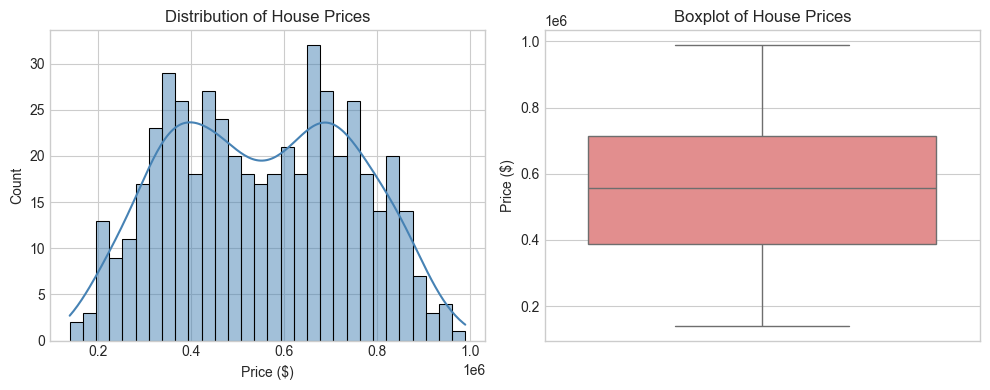

In [6]:
# Distribution of House Prices
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['Price'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price ($)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Price'], color='lightcoral')
plt.title('Boxplot of House Prices')
plt.ylabel('Price ($)')

plt.tight_layout()
plt.show()

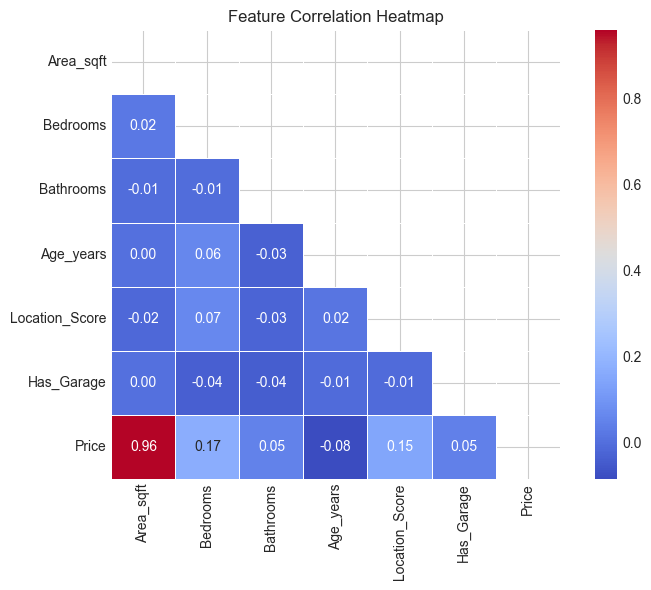

In [7]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

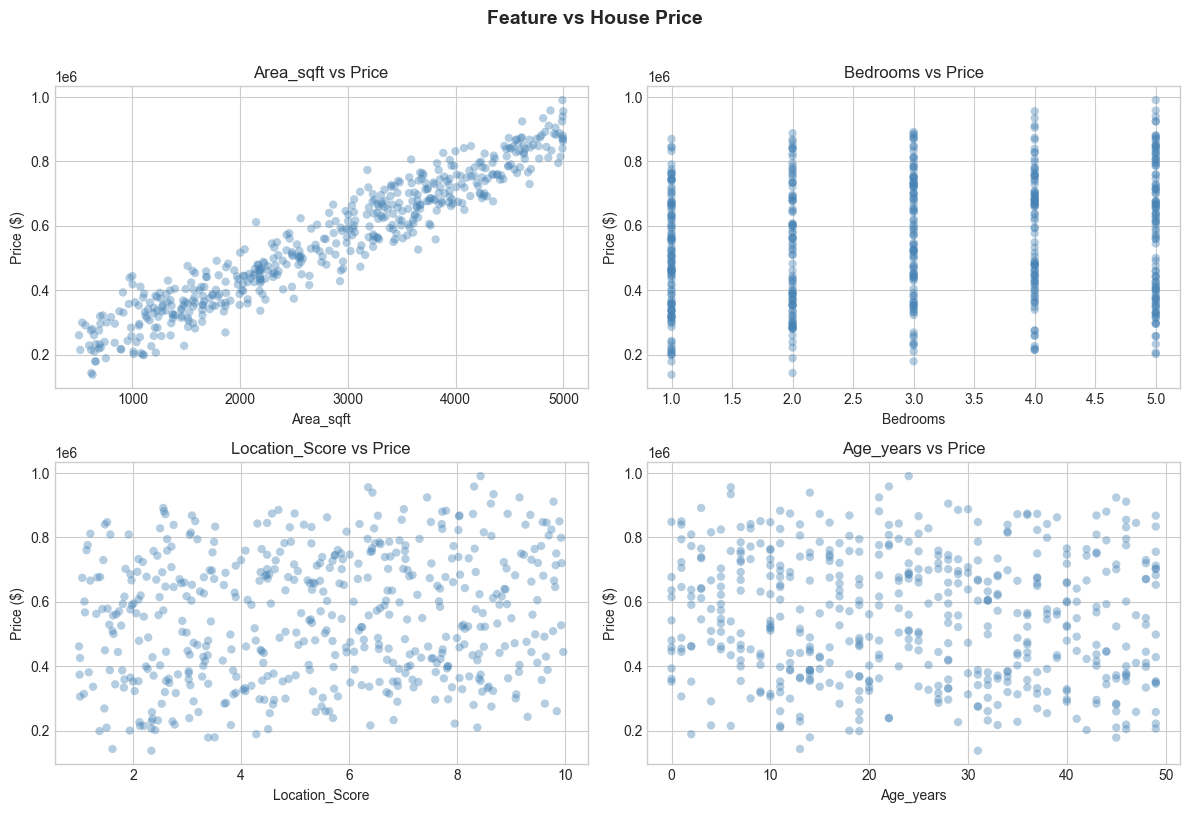

In [8]:
# Scatter plots of key features vs Price
features_to_plot = ['Area_sqft', 'Bedrooms', 'Location_Score', 'Age_years']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    axes[i].scatter(df[feat], df['Price'], alpha=0.4, color='steelblue', edgecolors='none')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Price ($)')
    axes[i].set_title(f'{feat} vs Price')

plt.suptitle('Feature vs House Price', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [9]:
# Features and target
X = df.drop('Price', axis=1)
y = df['Price']

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'\nFeatures used  : {list(X.columns)}')

Features shape : (500, 6)
Target shape   : (500,)

Features used  : ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Location_Score', 'Has_Garage']


In [10]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('Feature scaling complete.')
X_scaled.describe().round(2)

Feature scaling complete.


,Area_sqft,Bedrooms,Bathrooms,Age_years,Location_Score,Has_Garage
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,0.00,-0.00,-0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.83,-1.36,-1.20,-1.69,-1.74,-1.05
25%,-0.90,-0.67,-1.20,-0.85,-0.92,-1.05
50%,0.10,0.02,0.02,-0.02,0.03,0.96
75%,0.81,0.71,1.24,0.81,0.88,0.96
max,1.74,1.40,1.24,1.71,1.78,0.96


## 5. Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'Training set   : {X_train.shape[0]} samples')
print(f'Test set       : {X_test.shape[0]} samples')

Training set   : 400 samples
Test set       : 100 samples


## 6. Model Training — Linear Regression

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully!')
print(f'\nIntercept : {model.intercept_:,.2f}')
print('\nFeature Coefficients:')
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))

Model trained successfully!

Intercept : 551,725.19

Feature Coefficients:
       Feature   Coefficient
     Area_sqft 185190.318440
Location_Score  29947.620626
      Bedrooms  27977.530775
     Bathrooms  12304.422769
    Has_Garage   9977.193967
     Age_years -18891.057324


## 7. Model Evaluation

In [13]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'--- {label} ---')
    print(f'  MAE  : ${mae:>12,.2f}')
    print(f'  RMSE : ${rmse:>12,.2f}')
    print(f'  R²   : {r2:.4f}')
    print()

evaluate(y_train, y_pred_train, 'Training Set')
evaluate(y_test,  y_pred_test,  'Test Set')

--- Training Set ---
  MAE  : $   23,846.19
  RMSE : $   29,609.86
  R²   : 0.9773

--- Test Set ---
  MAE  : $   22,301.19
  RMSE : $   28,508.45
  R²   : 0.9764



## 8. Visualizations

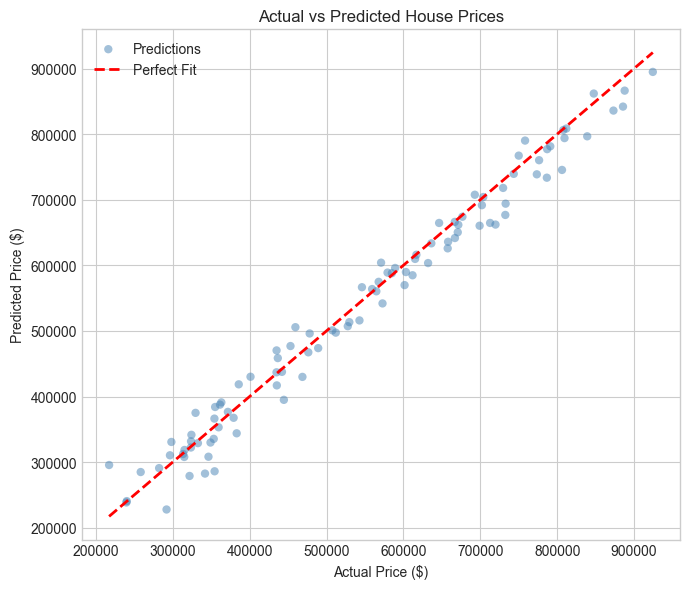

In [14]:
# Actual vs Predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5, color='steelblue', edgecolors='none', label='Predictions')
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()

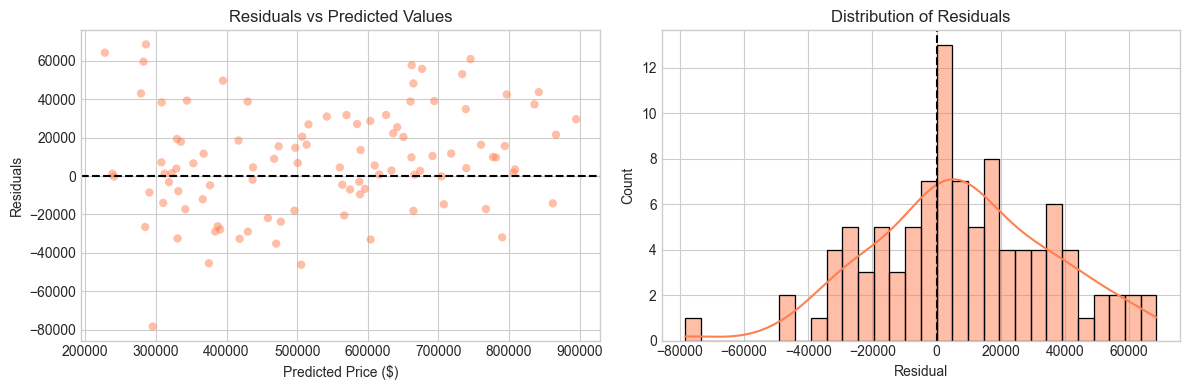

In [15]:
# Residual Plot
residuals = y_test - y_pred_test

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_test, residuals, alpha=0.5, color='coral', edgecolors='none')
plt.axhline(0, color='black', linestyle='--', lw=1.5)
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')

plt.subplot(1, 2, 2)
sns.histplot(residuals, bins=30, kde=True, color='coral')
plt.axvline(0, color='black', linestyle='--', lw=1.5)
plt.xlabel('Residual')
plt.title('Distribution of Residuals')

plt.tight_layout()
plt.show()

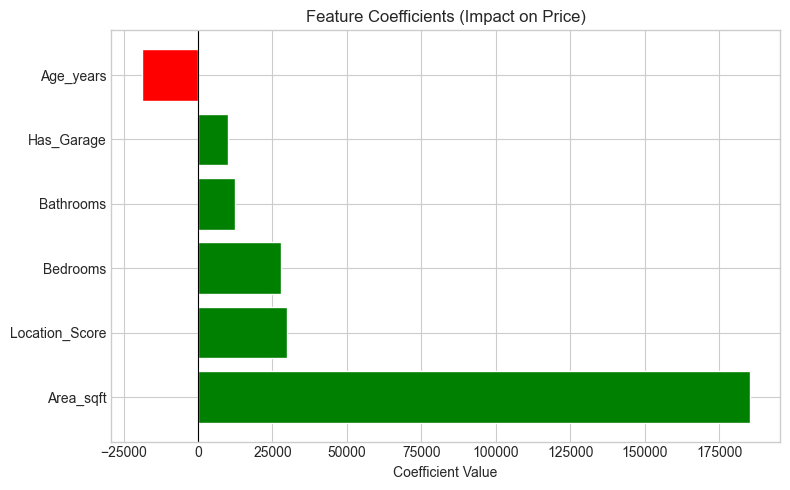

In [16]:
# Feature Importance (Coefficients)
plt.figure(figsize=(8, 5))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients (Impact on Price)')
plt.tight_layout()
plt.show()

## 9. Predict on New House Data

In [17]:
# Example: Predict price for a new house
new_house = pd.DataFrame([{
    'Area_sqft'     : 2500,
    'Bedrooms'      : 4,
    'Bathrooms'     : 2,
    'Age_years'     : 10,
    'Location_Score': 7.5,
    'Has_Garage'    : 1
}])

print('Input House Features:')
print(new_house.to_string(index=False))

# Scale using the same scaler
new_house_scaled = scaler.transform(new_house)

predicted_price = model.predict(new_house_scaled)[0]
print(f'\n🏠 Predicted House Price: ${predicted_price:,.2f}')

Input House Features:
 Area_sqft  Bedrooms  Bathrooms  Age_years  Location_Score  Has_Garage
      2500         4          2         10             7.5           1

🏠 Predicted House Price: $579,499.34


In [18]:
# Batch prediction example
batch = pd.DataFrame([
    {'Area_sqft': 1200, 'Bedrooms': 2, 'Bathrooms': 1, 'Age_years': 20, 'Location_Score': 5.0, 'Has_Garage': 0},
    {'Area_sqft': 3000, 'Bedrooms': 4, 'Bathrooms': 3, 'Age_years': 5,  'Location_Score': 8.5, 'Has_Garage': 1},
    {'Area_sqft': 4500, 'Bedrooms': 5, 'Bathrooms': 3, 'Age_years': 2,  'Location_Score': 9.2, 'Has_Garage': 1},
    {'Area_sqft': 800,  'Bedrooms': 1, 'Bathrooms': 1, 'Age_years': 40, 'Location_Score': 3.0, 'Has_Garage': 0},
])

batch_scaled    = scaler.transform(batch)
batch['Predicted_Price'] = model.predict(batch_scaled).round(2)

print('Batch Predictions:')
batch

Batch Predictions:


,Area_sqft,Bedrooms,Bathrooms,Age_years,Location_Score,Has_Garage,Predicted_Price
0,1200,2,1,20,5.0,0,272438.69
1,3000,4,3,5,8.5,1,686271.98
2,4500,5,3,2,9.2,1,938158.35
3,800,1,1,40,3.0,0,144672.56
